In [ ]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(lubridate)
})

options(dplyr.summarise.inform = FALSE)

Warning message:
"package 'ggplot2' was built under R version 4.4.3"


In [ ]:
proj_dir <- normalizePath(getwd())
if (!file.exists(file.path(proj_dir, "data_processed", "canada_model_common_window.csv"))) {
  proj_dir <- "/Users/siddarthchilukuri/Documents/Github/STAT443-Project"
}
data_processed_dir <- file.path(proj_dir, "data_processed")
output_tables_dir <- file.path(proj_dir, "output", "tables")
output_figures_dir <- file.path(proj_dir, "output", "figures")

dir.create(output_tables_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(output_figures_dir, recursive = TRUE, showWarnings = FALSE)

seed <- 443
set.seed(seed)

In [ ]:
can_path <- file.path(data_processed_dir, "canada_model_common_window.csv")
us_path <- file.path(data_processed_dir, "us_model_common_window.csv")

can_df <- readr::read_csv(can_path, show_col_types = FALSE)
us_df <- readr::read_csv(us_path, show_col_types = FALSE)

glimpse(can_df)
glimpse(us_df)

Rows: 263
Columns: 7
$ month         <date> 2004-03-01, 2004-04-01, 2004-05-01, 2004-06-01, 2004-07~
$ infl          <dbl> 0.0000000000, 0.0028887839, 0.0067082187, 0.0009546540, ~
$ gdp_can_l1    <dbl> -0.0006390014, 0.0088502445, 0.0025381814, 0.0009578100,~
$ unemp_can_l1  <dbl> 7.3, 7.3, 7.2, 7.1, 7.2, 7.1, 7.0, 6.9, 7.1, 7.2, 7.1, 6~
$ ippi_can_l1   <dbl> 0.020151815, 0.006215060, 0.012315427, 0.012165600, -0.0~
$ oil_wti_l1    <dbl> 0.0110146041, 0.0574146188, 0.0002721459, 0.0917168422, ~
$ exrate_can_l1 <dbl> -0.026183538, 0.004049219, -0.005298438, -0.022970139, 0~
Rows: 260
Columns: 7
$ month      <date> 2004-03-01, 2004-04-01, 2004-05-01, 2004-06-01, 2004-07-01~
$ infl       <dbl> 0.0021401827, 0.0016021365, 0.0042598573, 0.0037125474, 0.0~
$ gdp_us_l1  <dbl> 2.5190134, 3.6822955, 2.3436157, 3.8651909, 3.1528981, 4.44~
$ u6_us_l1   <dbl> 9.7, 10.0, 9.6, 9.7, 9.6, 9.5, 9.4, 9.4, 9.7, 9.4, 9.3, 9.2~
$ ppi_us_l1  <dbl> 0.0000000000, 0.0059701670, 0.0046189459, 0.0052528026, 0.0

In [ ]:
clean_model_df <- function(df) {
  df %>%
    janitor::clean_names() %>%
    mutate(month = as.Date(month)) %>%
    arrange(month) %>%
    distinct(month, .keep_all = TRUE)
}

if (!requireNamespace("janitor", quietly = TRUE)) {
  clean_model_df <- function(df) {
    names(df) <- tolower(gsub("[^A-Za-z0-9]+", "_", names(df)))
    df %>% mutate(month = as.Date(month)) %>% arrange(month) %>% distinct(month, .keep_all = TRUE)
  }
}

can_df <- clean_model_df(can_df)
us_df <- clean_model_df(us_df)

colSums(is.na(can_df))
colSums(is.na(us_df))

Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00C4>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00D6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00DC>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00E4>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00F6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00FC>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00DF>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00C6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00E6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00D8>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00F8>' to native encoding"
Warning message in FU

month          infl    gdp_can_l1  unemp_can_l1   ippi_can_l1 
            0             0             0             0             0 
   oil_wti_l1 exrate_can_l1 
            0             0

month       infl  gdp_us_l1   u6_us_l1  ppi_us_l1 oil_wti_l1  mxp_us_l1 
         0          0          0          0          0          0          0

In [ ]:
summary_can <- can_df %>% summarise(across(where(is.numeric), list(mean = mean, sd = sd), na.rm = TRUE))
summary_us <- us_df %>% summarise(across(where(is.numeric), list(mean = mean, sd = sd), na.rm = TRUE))

corr_can <- can_df %>% select(-month) %>% cor(use = "pairwise.complete.obs")
corr_us <- us_df %>% select(-month) %>% cor(use = "pairwise.complete.obs")

summary_can
summary_us

Warning message:
"There was 1 warning in `summarise()`.
i In argument: `across(where(is.numeric), list(mean = mean, sd = sd), na.rm =
  TRUE)`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))"


infl_mean,infl_sd,gdp_can_l1_mean,gdp_can_l1_sd,unemp_can_l1_mean,unemp_can_l1_sd,ippi_can_l1_mean,ippi_can_l1_sd,oil_wti_l1_mean,oil_wti_l1_sd,exrate_can_l1_mean,exrate_can_l1_sd
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.001793497,0.002798497,0.001607252,0.0103268,6.901141,1.201605,0.00207633,0.007114271,0.001994254,0.1041113,3.081578e-06,0.01578733


infl_mean,infl_sd,gdp_us_l1_mean,gdp_us_l1_sd,u6_us_l1_mean,u6_us_l1_sd,ppi_us_l1_mean,ppi_us_l1_sd,oil_wti_l1_mean,oil_wti_l1_sd,mxp_us_l1_mean,mxp_us_l1_sd
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.002129628,0.003149174,2.122069,7.25244,10.52346,3.407128,0.002210228,0.003300893,0.002312984,0.1046545,0.000956071,0.004203753


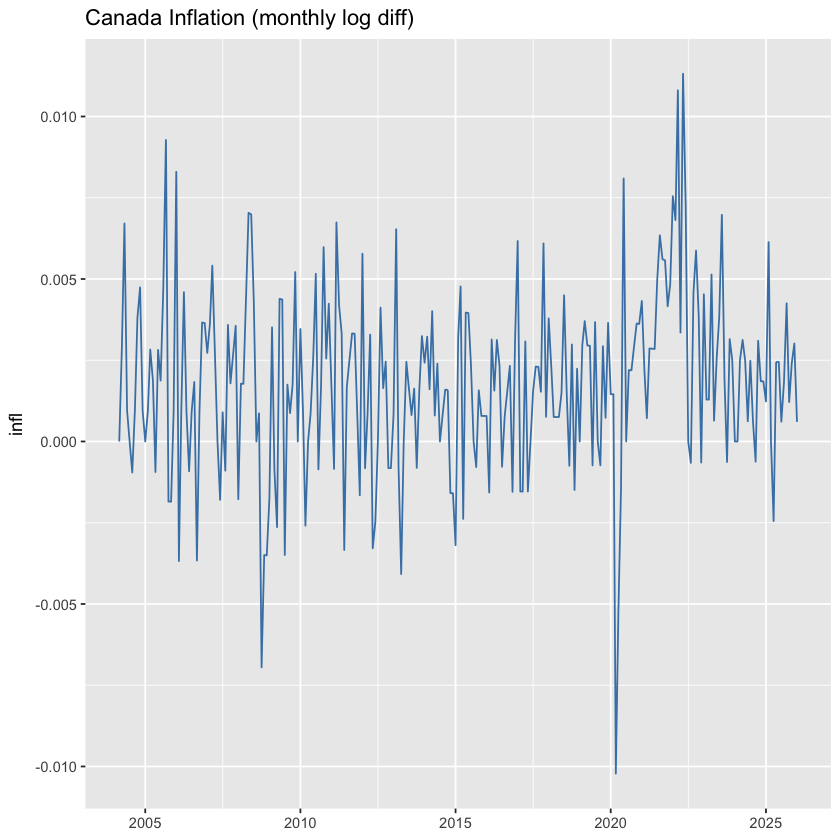

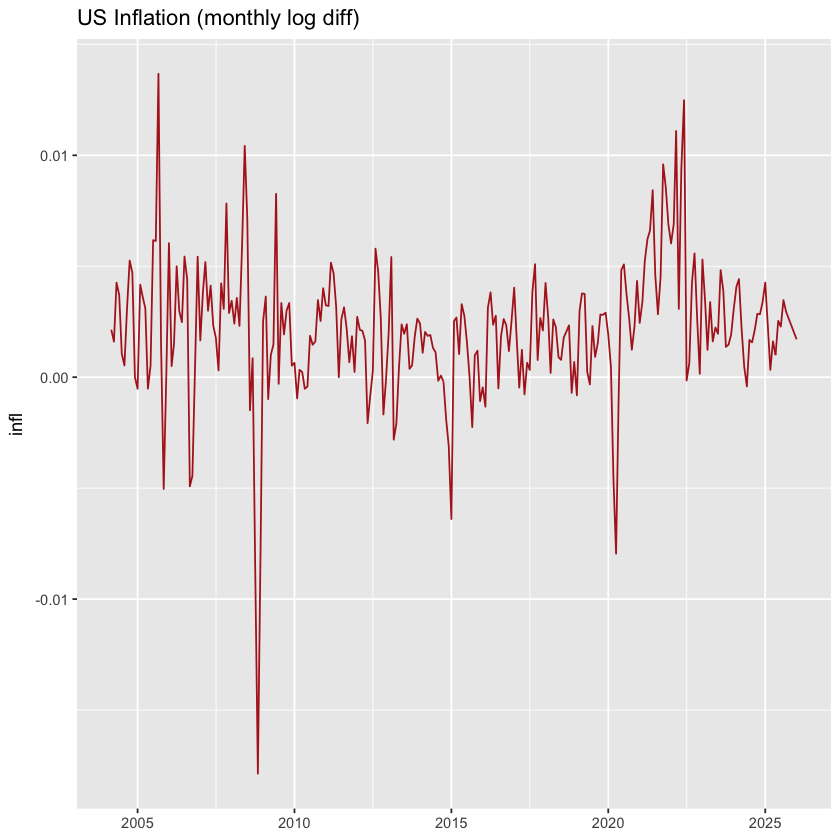

In [ ]:
p_can_infl <- ggplot(can_df, aes(month, infl)) +
  geom_line(color = "steelblue") +
  labs(title = "Canada Inflation (monthly log diff)", x = NULL, y = "infl")

p_us_infl <- ggplot(us_df, aes(month, infl)) +
  geom_line(color = "firebrick") +
  labs(title = "US Inflation (monthly log diff)", x = NULL, y = "infl")

p_can_infl
p_us_infl

In [ ]:
make_baseline <- function(df) {
  d <- df %>% mutate(infl_l1 = lag(infl)) %>% drop_na(infl, infl_l1)
  cutoff <- floor(0.8 * nrow(d))
  train <- d[1:cutoff, ]
  test <- d[(cutoff + 1):nrow(d), ]
  fit <- lm(infl ~ infl_l1, data = train)
  test$pred <- predict(fit, newdata = test)
  list(fit = fit, train = train, test = test)
}

base_can <- make_baseline(can_df)
base_us <- make_baseline(us_df)

summary(base_can$fit)
summary(base_us$fit)


Call:
lm(formula = infl ~ infl_l1, data = train)

Residuals:
       Min         1Q     Median         3Q        Max 
-0.0117286 -0.0016937  0.0001668  0.0017841  0.0072895 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0012939  0.0002135   6.060 6.35e-09 ***
infl_l1     0.1484088  0.0692217   2.144   0.0332 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.002706 on 207 degrees of freedom
Multiple R-squared:  0.02172,	Adjusted R-squared:  0.017 
F-statistic: 4.597 on 1 and 207 DF,  p-value: 0.0332



Call:
lm(formula = infl ~ infl_l1, data = train)

Residuals:
       Min         1Q     Median         3Q        Max 
-0.0145571 -0.0011343  0.0000936  0.0013628  0.0097424 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0009245  0.0002204   4.195 4.07e-05 ***
infl_l1     0.4899991  0.0617626   7.934 1.36e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.002762 on 205 degrees of freedom
Multiple R-squared:  0.2349,	Adjusted R-squared:  0.2312 
F-statistic: 62.94 on 1 and 205 DF,  p-value: 1.362e-13


In [ ]:
calc_metrics <- function(test_df) {
  tibble(
    mae = mean(abs(test_df$infl - test_df$pred), na.rm = TRUE),
    rmse = sqrt(mean((test_df$infl - test_df$pred)^2, na.rm = TRUE))
  )
}

metrics_can <- calc_metrics(base_can$test) %>% mutate(country = "Canada")
metrics_us <- calc_metrics(base_us$test) %>% mutate(country = "United States")
metrics_all <- bind_rows(metrics_can, metrics_us) %>% select(country, mae, rmse)

metrics_all

country,mae,rmse
<chr>,<dbl>,<dbl>
Canada,0.002241478,0.002938734
United States,0.001828184,0.002631140


In [ ]:
metrics_path <- file.path(output_tables_dir, "baseline_metrics.csv")
corr_can_path <- file.path(output_tables_dir, "canada_correlations.csv")
corr_us_path <- file.path(output_tables_dir, "us_correlations.csv")
plot_can_path <- file.path(output_figures_dir, "canada_inflation_series.png")
plot_us_path <- file.path(output_figures_dir, "us_inflation_series.png")

readr::write_csv(metrics_all, metrics_path)
readr::write_csv(as.data.frame(corr_can) %>% rownames_to_column("variable"), corr_can_path)
readr::write_csv(as.data.frame(corr_us) %>% rownames_to_column("variable"), corr_us_path)
ggsave(plot_can_path, p_can_infl, width = 8, height = 4, dpi = 150)
ggsave(plot_us_path, p_us_infl, width = 8, height = 4, dpi = 150)

cat("Saved:\n", metrics_path, "\n", corr_can_path, "\n", corr_us_path, "\n", plot_can_path, "\n", plot_us_path, "\n")

Saved:
 /Users/siddarthchilukuri/Desktop/443/project/output/tables/baseline_metrics.csv 
 /Users/siddarthchilukuri/Desktop/443/project/output/tables/canada_correlations.csv 
 /Users/siddarthchilukuri/Desktop/443/project/output/tables/us_correlations.csv 
 /Users/siddarthchilukuri/Desktop/443/project/output/figures/canada_inflation_series.png 
 /Users/siddarthchilukuri/Desktop/443/project/output/figures/us_inflation_series.png 


In [ ]:
suppressPackageStartupMessages({
  library(glmnet)
  library(forecast)
})

calc_metrics_vec <- function(actual, pred) {
  tibble(
    mae = mean(abs(actual - pred), na.rm = TRUE),
    rmse = sqrt(mean((actual - pred)^2, na.rm = TRUE))
  )
}

expanding_forecast_models <- function(df, country_name, min_train_n = 120) {
  d <- df %>%
    arrange(month) %>%
    mutate(infl_l1 = lag(infl)) %>%
    drop_na()

  feature_cols <- setdiff(names(d), c("month", "infl"))
  preds <- vector("list", max(0, nrow(d) - min_train_n))
  idx <- 1L

  for (i in seq(min_train_n, nrow(d) - 1)) {
    train <- d[1:i, ]
    test <- d[i + 1, , drop = FALSE]

    fit_ar1 <- lm(infl ~ infl_l1, data = train)
    pred_ar1 <- as.numeric(predict(fit_ar1, newdata = test))

    fit_ols <- lm(
      as.formula(paste("infl ~", paste(feature_cols, collapse = " + "))),
      data = train
    )
    pred_ols <- as.numeric(predict(fit_ols, newdata = test))

    x_train <- as.matrix(train[, feature_cols])
    y_train <- train$infl
    x_test <- as.matrix(test[, feature_cols, drop = FALSE])

    cvfit <- cv.glmnet(
      x = x_train,
      y = y_train,
      alpha = 1,
      nfolds = 5,
      standardize = TRUE
    )
    pred_lasso <- as.numeric(predict(cvfit, newx = x_test, s = "lambda.min"))

    fit_arima <- forecast::auto.arima(
      train$infl,
      seasonal = FALSE,
      stepwise = TRUE,
      approximation = TRUE
    )
    pred_arima <- as.numeric(forecast::forecast(fit_arima, h = 1)$mean[1])

    preds[[idx]] <- tibble(
      country = country_name,
      month = test$month,
      actual = test$infl,
      pred_benchmark = pred_ar1,
      pred_multivariate = pred_ols,
      pred_lasso = pred_lasso,
      pred_arima = pred_arima
    )
    idx <- idx + 1L
  }

  bind_rows(preds)
}

Warning message:
"package 'forecast' was built under R version 4.4.3"


In [ ]:
pred_can <- expanding_forecast_models(can_df, "Canada")
pred_us <- expanding_forecast_models(us_df, "United States")
pred_all <- bind_rows(pred_can, pred_us)

metrics_long <- pred_all %>%
  tidyr::pivot_longer(
    cols = c(pred_benchmark, pred_multivariate, pred_lasso, pred_arima),
    names_to = "model",
    values_to = "pred"
  ) %>%
  group_by(country, model) %>%
  summarise(
    mae = mean(abs(actual - pred), na.rm = TRUE),
    rmse = sqrt(mean((actual - pred)^2, na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(
    model_label = recode(
      model,
      pred_benchmark = "Benchmark AR(1)",
      pred_multivariate = "Multivariate OLS",
      pred_lasso = "LASSO",
      pred_arima = "ARIMA"
    )
  )

rank_table <- metrics_long %>%
  group_by(country) %>%
  arrange(rmse, .by_group = TRUE) %>%
  mutate(rmse_rank = row_number()) %>%
  ungroup()

winner_table <- rank_table %>%
  filter(rmse_rank == 1) %>%
  transmute(country, winner_model = model_label, winner_rmse = rmse, winner_mae = mae)

metrics_path <- file.path(output_tables_dir, "lean_metrics_expanding_window.csv")
preds_path <- file.path(output_tables_dir, "lean_predictions_expanding_window.csv")
rank_path <- file.path(output_tables_dir, "lean_model_ranking_by_country.csv")
winner_path <- file.path(output_tables_dir, "lean_winning_model_by_country.csv")

readr::write_csv(metrics_long, metrics_path)
readr::write_csv(pred_all, preds_path)
readr::write_csv(rank_table, rank_path)
readr::write_csv(winner_table, winner_path)

rank_table
winner_table

country,model,mae,rmse,model_label,rmse_rank
<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>
Canada,pred_lasso,0.001926439,0.002598140,LASSO,1
Canada,pred_multivariate,0.001963399,0.002641382,Multivariate OLS,2
Canada,pred_benchmark,0.002024306,0.002672995,Benchmark AR(1),3
Canada,pred_arima,0.002058755,0.002720516,ARIMA,4
United States,pred_benchmark,0.001674199,0.002308308,Benchmark AR(1),1
United States,pred_lasso,0.001681615,0.002316835,LASSO,2
United States,pred_arima,0.001733117,0.002358834,ARIMA,3
United States,pred_multivariate,0.001758339,0.002536738,Multivariate OLS,4


country,winner_model,winner_rmse,winner_mae
<chr>,<chr>,<dbl>,<dbl>
Canada,LASSO,0.002598140,0.001926439
United States,Benchmark AR(1),0.002308308,0.001674199


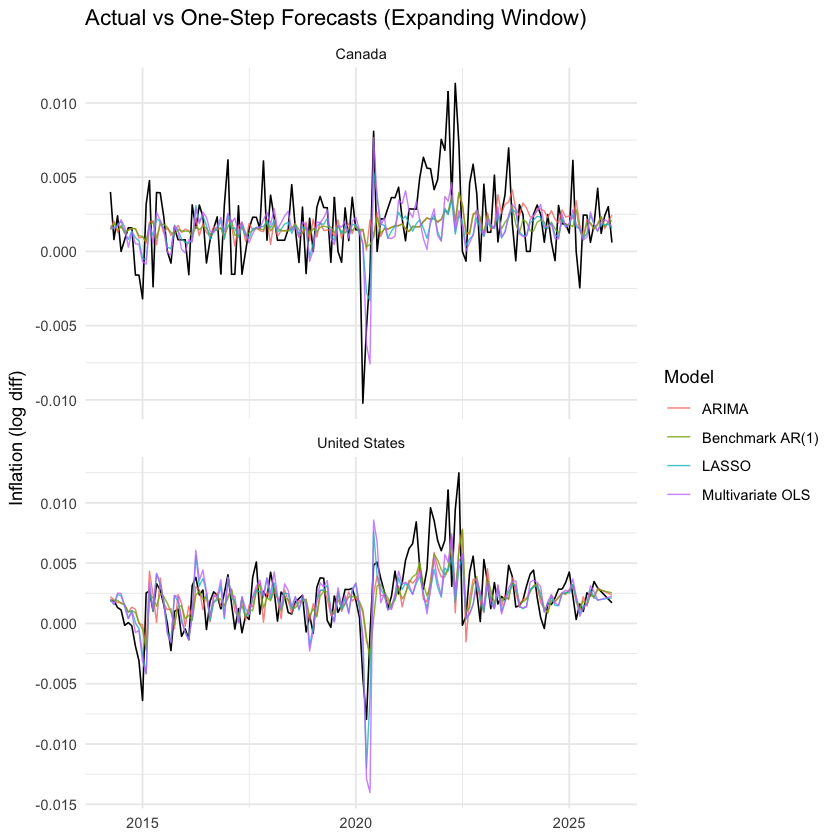

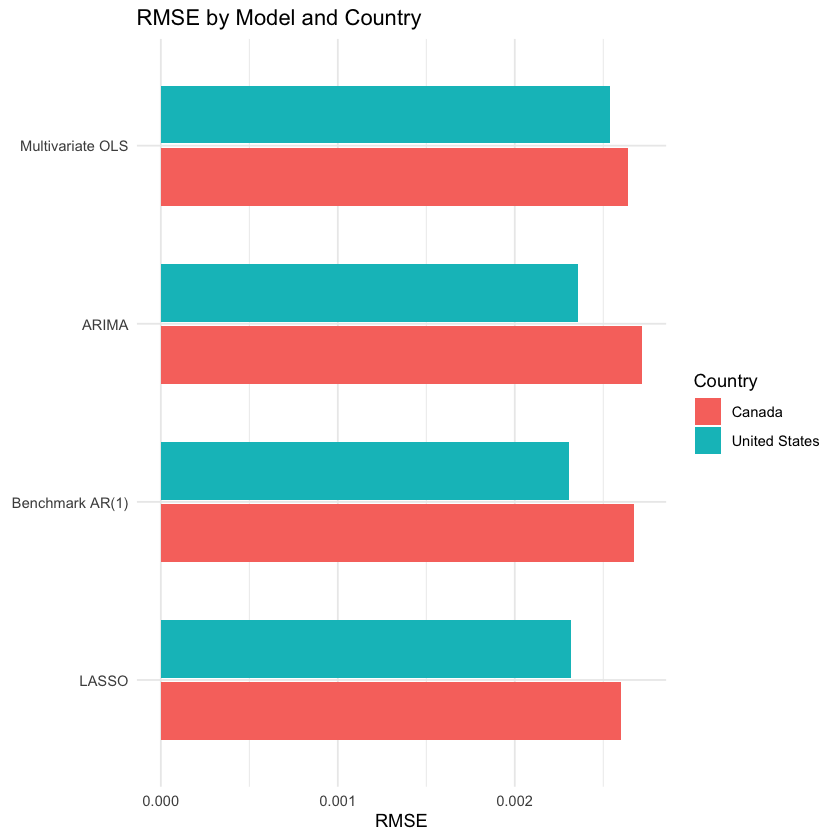

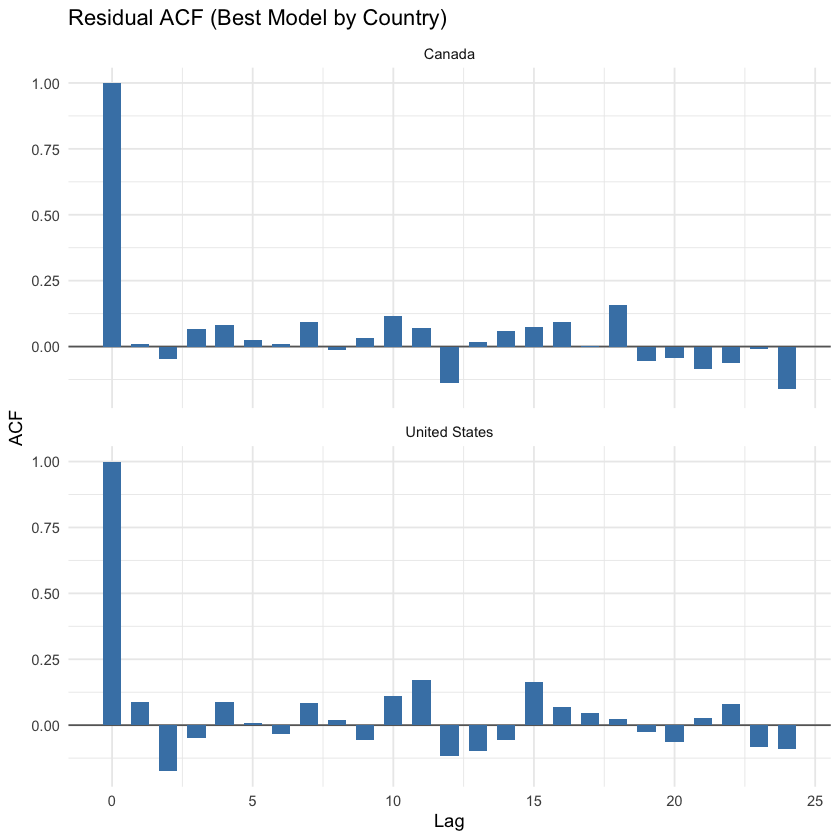

In [ ]:
plot_long <- pred_all %>%
  tidyr::pivot_longer(
    cols = c(pred_benchmark, pred_multivariate, pred_lasso, pred_arima),
    names_to = "model",
    values_to = "pred"
  ) %>%
  mutate(
    model_label = recode(
      model,
      pred_benchmark = "Benchmark AR(1)",
      pred_multivariate = "Multivariate OLS",
      pred_lasso = "LASSO",
      pred_arima = "ARIMA"
    )
  )

p_forecast <- ggplot(plot_long, aes(x = month)) +
  geom_line(aes(y = actual), color = "black", linewidth = 0.45) +
  geom_line(aes(y = pred, color = model_label), alpha = 0.8, linewidth = 0.4) +
  facet_wrap(~ country, scales = "free_y", ncol = 1) +
  labs(
    title = "Actual vs One-Step Forecasts (Expanding Window)",
    x = NULL,
    y = "Inflation (log diff)",
    color = "Model"
  ) +
  theme_minimal()

p_rmse <- rank_table %>%
  ggplot(aes(x = reorder(model_label, rmse), y = rmse, fill = country)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.65) +
  coord_flip() +
  labs(
    title = "RMSE by Model and Country",
    x = NULL,
    y = "RMSE",
    fill = "Country"
  ) +
  theme_minimal()

best_models <- winner_table %>% select(country, winner_model)

get_winner <- function(country_name) {
  winner <- best_models %>% filter(country == country_name) %>% pull(winner_model)
  if (length(winner) == 0 || is.na(winner[1])) "Benchmark AR(1)" else winner[1]
}

plot_resid_acf <- function(df, country_name, winner_name) {
  d <- df %>% arrange(month) %>% mutate(infl_l1 = lag(infl)) %>% drop_na()
  if (winner_name == "ARIMA") {
    fit <- forecast::auto.arima(d$infl, seasonal = FALSE, stepwise = TRUE, approximation = TRUE)
    res <- residuals(fit)
  } else {
    fit <- lm(infl ~ infl_l1, data = d)
    res <- residuals(fit)
  }

  acf_vals <- as.numeric(stats::acf(res, plot = FALSE)$acf)
  tibble(
    lag = seq_along(acf_vals) - 1,
    acf = acf_vals,
    country = country_name
  )
}

acf_can <- plot_resid_acf(can_df, "Canada", get_winner("Canada"))
acf_us <- plot_resid_acf(us_df, "United States", get_winner("United States"))
acf_all <- bind_rows(acf_can, acf_us)

p_acf <- ggplot(acf_all %>% filter(lag <= 24), aes(lag, acf)) +
  geom_hline(yintercept = 0, color = "gray40") +
  geom_col(width = 0.65, fill = "steelblue") +
  facet_wrap(~ country, ncol = 1) +
  labs(title = "Residual ACF (Best Model by Country)", x = "Lag", y = "ACF") +
  theme_minimal()

forecast_plot_path <- file.path(output_figures_dir, "lean_forecast_comparison.png")
rmse_plot_path <- file.path(output_figures_dir, "lean_model_ranking_rmse.png")
acf_plot_path <- file.path(output_figures_dir, "lean_residual_acf.png")

ggsave(forecast_plot_path, p_forecast, width = 10, height = 7, dpi = 150)
ggsave(rmse_plot_path, p_rmse, width = 9, height = 5, dpi = 150)
ggsave(acf_plot_path, p_acf, width = 10, height = 6, dpi = 150)

p_forecast
p_rmse
p_acf